# Learnings
- You can implement neural networks using numpy, torch, torch.nn, autograd, optim
- You can do individual weights (a, b, c, d) using `nn.Paramater(torch.randn())` if you don't wanna use `nn.Linear` and `nn.Flatten`, like you did in torch/numpy
- Optimizer is set up for model weights, so always do `optim = torch.optim.SGD(model.parameters(), lr=1e-6)`
- If you dont wanna use optim class, you can loop over `model.parameters()` and update/zero grad the param.grad manually in a for loop
- In the model class that inherits `nn.Module()`, when you do nn.Linear(x, y), you ignore the batch dimension, just focus on the shapes, the data loader takes care of the batch dim

In [ ]:
# https://docs.pytorch.org/tutorials/beginner/pytorch_with_examples.html

In [ ]:
# Warm-up: NumPy

In [ ]:
import numpy as np
import math
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [ ]:
## Implement a neural network using numpy and equation is:  # y = a + b x + c x^2 + d x^3

In [ ]:
### Input and output
x = np.linspace(-math.pi, math.pi, 2000)
y = np.sin(x)

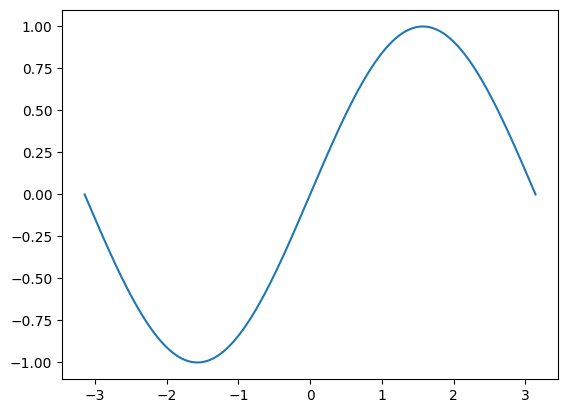

In [ ]:
### Plot the input and output
plt.plot(x, y)

In [ ]:
### Randomly init the weights for equation: # y = a + b x + c x^2 + d x^3
a = np.random.randn()
b = np.random.randn()
c = np.random.randn()
d = np.random.randn()

In [ ]:
### Training loop (2000 epochs, each epoch contains the entire training set)
learning_rate = 1e-6
for t in range(20000):
  #### Forward pass
  y_pred = a + b * x + c * x ** 2 + d * x ** 3

  #### Compute loss (SSE) and print every 100 epochs
  loss = np.square(y_pred - y).sum()
  if t % 100 == 0:
    print(t, loss)

  #### Backprop, which means calculate gradients
  grad_y_pred = 2.0 * (y_pred - y)
  grad_a = grad_y_pred.sum()
  grad_b = (grad_y_pred * x).sum()
  grad_c = (grad_y_pred * x ** 2).sum()
  grad_d = (grad_y_pred * x ** 3).sum()

  #### Optimizer step
  a -= learning_rate * grad_a
  b -= learning_rate * grad_b
  c -= learning_rate * grad_c
  d -= learning_rate * grad_d

0 8.817165410445654
100 8.817165410316427
200 8.817165410225318
300 8.817165410161067
400 8.817165410115747
500 8.817165410083774
600 8.817165410061211
700 8.817165410045286
800 8.817165410034045
900 8.817165410026112
1000 8.817165410020507
1100 8.817165410016548
1200 8.817165410013754
1300 8.81716541001178
1400 8.817165410010386
1500 8.817165410009402
1600 8.817165410008705
1700 8.81716541000821
1800 8.817165410007863
1900 8.81716541000762
2000 8.817165410007444
2100 8.817165410007322
2200 8.817165410007235
2300 8.817165410007172
2400 8.817165410007128
2500 8.8171654100071
2600 8.817165410007076
2700 8.81716541000706
2800 8.81716541000705
2900 8.817165410007044
3000 8.81716541000704
3100 8.817165410007036
3200 8.81716541000703
3300 8.81716541000703
3400 8.817165410007028
3500 8.817165410007028
3600 8.817165410007025
3700 8.817165410007025
3800 8.817165410007025
3900 8.817165410007025
4000 8.817165410007025
4100 8.817165410007025
4200 8.817165410007025
4300 8.817165410007023
4400 8.817

In [ ]:
y_pred

array([ 0.20229713,  0.19631286,  0.19034597, ..., -0.19034597,
       -0.19631286, -0.20229713])

In [ ]:
y

array([-1.22464680e-16, -3.14315906e-03, -6.28628707e-03, ...,
        6.28628707e-03,  3.14315906e-03,  1.22464680e-16])

# Implement the same neural network using torch

In [ ]:
import torch
import math
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [ ]:
device = torch.device('cpu')
dtype = torch.float

In [ ]:
x = torch.linspace(-math.pi, math.pi, 2000, device=device, dtype=dtype)
y = torch.sin(x)

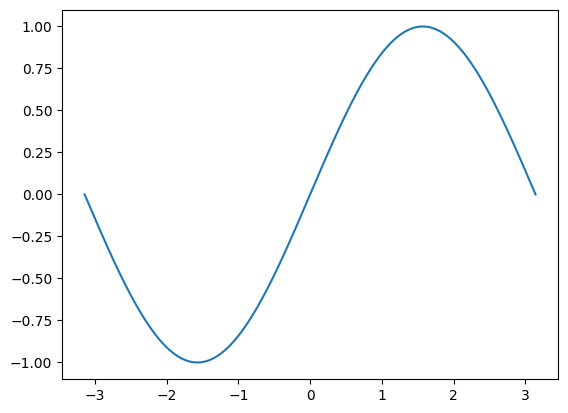

In [ ]:
plt.plot(x, y)

In [ ]:
# Define random weights
a = torch.randn((), device=device, dtype=dtype)
b = torch.randn((), device=device, dtype=dtype)
c = torch.randn((), device=device, dtype=dtype)
d = torch.randn((), device=device, dtype=dtype)

# Define learning rate
lr = 1e-6

In [ ]:
# Training loop
for i in range(2000):
  # Forward pass
  y_pred = a + (b * x) + (c * x ** 2) + (d * x ** 3)

  # Loss
  # L = sum[(y_pred - y) ** 2]
  loss = torch.sum(torch.square(y_pred - y)).item()
  if i % 100 == 0:
    print(loss)

  # Gradients
    # dL/d_param = dL/dy_pred * dy_pred/d_param
    # dL/dy_pred = 2 * (y_pred - y)
    # dy_pred/d_param = dL/dy_pred * (...)
  grad_y_pred = 2.0 * (y_pred - y)
  grad_a = torch.sum(grad_y_pred)
  grad_b = torch.sum(grad_y_pred * x)
  grad_c = torch.sum(grad_y_pred * x ** 2)
  grad_d = torch.sum(grad_y_pred * x ** 3)

  # Optimizer
  a -= lr * grad_a
  b -= lr * grad_b
  c -= lr * grad_c
  d -= lr * grad_d

8.817166328430176
8.817167282104492
8.817167282104492
8.817167282104492
8.817167282104492
8.817167282104492
8.817167282104492
8.817167282104492
8.817167282104492
8.817167282104492
8.817167282104492
8.817167282104492
8.817167282104492
8.817167282104492
8.817167282104492
8.817167282104492
8.817167282104492
8.817167282104492
8.817167282104492
8.817167282104492


In [ ]:
print(f'Result: y = {a.item()} + {b.item()} x + {c.item()} x^2 + {d.item()} x^3')

Result: y = 1.6747531361716028e-08 + 0.8567550778388977 x + -1.0941838546330018e-08 x^2 + -0.09333240985870361 x^3


# Now do the same with pytorch autograd

In [ ]:
x = torch.linspace(-math.pi, math.pi, 2000, device=device, dtype=dtype)
y = torch.sin(x)

In [ ]:
# Define random weights
a = torch.randn((), device=device, dtype=dtype, requires_grad=True)
b = torch.randn((), device=device, dtype=dtype, requires_grad=True)
c = torch.randn((), device=device, dtype=dtype, requires_grad=True)
d = torch.randn((), device=device, dtype=dtype, requires_grad=True)

# Define learning rate
lr = 1e-6

In [ ]:
# Training loop
for i in range(2000):
  # Forward pass
  y_pred = a + (b * x) + (c * x ** 2) + (d * x ** 3)

  # Loss
  # L = sum[(y_pred - y) ** 2]
  loss = torch.sum(torch.square(y_pred - y))
  if i % 100 == 0:
    print(loss.item())

  # Zero Grad
  a.grad = None
  b.grad = None
  c.grad = None
  d.grad = None

  # Gradients
  loss.backward()

  # Optimizer
  with torch.no_grad():
    a -= lr * a.grad
    b -= lr * b.grad
    c -= lr * c.grad
    d -= lr * d.grad

8.817514419555664
8.817411422729492
8.817340850830078
8.817288398742676
8.817253112792969
8.817228317260742
8.81721019744873
8.817197799682617
8.817188262939453
8.817180633544922
8.817177772521973
8.817173957824707
8.817171096801758
8.817171096801758
8.817169189453125
8.817168235778809
8.817169189453125
8.817167282104492
8.817167282104492
8.817167282104492


# Now do the same with nn.Module

In [ ]:
x = torch.linspace(-math.pi, math.pi, 2000)
y = torch.sin(x)
p = torch.tensor([1, 2, 3])
xx = x.unsqueeze(-1).pow(p)

In [ ]:
class LinearModel(torch.nn.Module):
  def __init__(self):
    super(LinearModel, self).__init__()
    self.layers = torch.nn.Sequential(
        torch.nn.Linear(3, 1),
        torch.nn.Flatten(0, 1)
    )

  def forward(self, x):
    return self.layers(x)

In [ ]:
model = LinearModel()

In [ ]:
loss_fn = torch.nn.MSELoss(reduction="sum")

In [ ]:
lr = 1e-6

In [ ]:
for i in range(2000):
  # Forward pass
  y_pred = model(xx)

  # Loss
  loss = loss_fn(y_pred, y)
  if i % 100 == 0:
    print(loss.item())

  # Backward pass
  for param in model.parameters():
      param.grad = None
  loss.backward()

  # Optimizer step
  with torch.no_grad():
    for param in model.parameters():
      param -= lr * param.grad

8.817168235778809
8.817168235778809
8.817168235778809
8.817168235778809
8.817167282104492
8.817167282104492
8.817167282104492
8.817167282104492
8.817168235778809
8.817168235778809
8.817167282104492
8.817167282104492
8.817168235778809
8.817168235778809
8.817168235778809
8.817168235778809
8.817168235778809
8.817168235778809
8.817168235778809
8.817167282104492


In [ ]:
# b, c, d
model.layers[0].weight

Parameter containing:
tensor([[ 8.5673e-01, -6.8458e-08, -9.3328e-02]], requires_grad=True)

In [ ]:
# a
model.layers[0].bias

Parameter containing:
tensor([3.8920e-07], requires_grad=True)

In [ ]:
linear_layer = model.layers[0]

In [ ]:
# For linear layer, its parameters are stored as `weight` and `bias`.
print(f'Result: y = {linear_layer.bias.item()} + {linear_layer.weight[:, 0].item()} x + {linear_layer.weight[:, 1].item()} x^2 + {linear_layer.weight[:, 2].item()} x^3')

Result: y = 3.891965434377198e-07 + 0.8567266464233398 x + -6.845770883501245e-08 x^2 + -0.09332837164402008 x^3


# Now do the same with optim

In [ ]:
x = torch.linspace(-math.pi, math.pi, 2000)
y = torch.sin(x)
p = torch.tensor([1, 2, 3])
xx = x.unsqueeze(-1).pow(p)

In [ ]:
class LinearModel(torch.nn.Module):
  def __init__(self):
    super(LinearModel, self).__init__()
    self.layers = torch.nn.Sequential(
        torch.nn.Linear(3, 1),
        torch.nn.Flatten(0, 1)
    )

  def forward(self, x):
    return self.layers(x)

In [ ]:
model = LinearModel()
loss_fn = torch.nn.MSELoss(reduction="sum")

In [ ]:
optimizer = torch.optim.RMSprop(model.parameters(), lr=1e-4)

In [ ]:
for i in range(2000):
  # Forward pass
  y_pred = model(xx)

  # Loss
  loss = loss_fn(y_pred, y)
  if i % 100 == 0:
    print(loss.item())

  # Backward pass
  optimizer.zero_grad()
  loss.backward()

  # Optimizer step
  optimizer.step()

8.81806755065918
8.81806755065918
8.81806755065918
8.81806755065918
8.81806755065918
8.81806755065918
8.81806755065918
8.81806755065918
8.81806755065918
8.81806755065918
8.81806755065918
8.81806755065918
8.81806755065918
8.81806755065918
8.81806755065918
8.81806755065918
8.81806755065918
8.81806755065918
8.81806755065918
8.81806755065918


In [ ]:
linear_layer = model.layers[0]
print(f'Result: y = {linear_layer.bias.item()} + {linear_layer.weight[:, 0].item()} x + {linear_layer.weight[:, 1].item()} x^2 + {linear_layer.weight[:, 2].item()} x^3')

Result: y = -1.3564195988635674e-08 + 0.8567908406257629 x + -4.759161953415969e-10 x^2 + -0.0932803824543953 x^3
